# **PART III — NLP (Spam vs Ham Classification)**

## **1. INSTALL & IMPORT LIBRARIES**

In [1]:
!pip install gensim
!pip install nltk seaborn gradio wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import gensim.downloader as api
import gradio as gr

## **2. DOWNLOAD NLTK RESOURCES**

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## **3. LOAD DATASET (Google Drive)**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/AI&ML/spamvsham.csv', encoding='latin1')
df.head()

Mounted at /content/drive


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## **4. CHECK & FIX COLUMNS**

In [5]:
print(df.columns)
print(df.shape)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
(5572, 5)


In [6]:
# Keep only relevant columns and drop unnamed/NaN-filled extra columns
df = df[['v1', 'v2']]
df = df.rename(columns={'v1': 'label', 'v2': 'text'})
df = df.dropna()
print(df.shape)
df.head()

(5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## **5. LABEL ENCODING**

In [7]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df['label'].value_counts())
print(f"Ham: {(df['label']==0).sum()}, Spam: {(df['label']==1).sum()}")

label
0    4825
1     747
Name: count, dtype: int64
Ham: 4825, Spam: 747


## **6. TEXT CLEANING**

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)      # remove URLs
    text = re.sub(r'@\w+|#\w+', ' ', text)           # remove mentions/hashtags
    text = re.sub(r'\d+', ' ', text)                  # remove numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)            # remove special characters
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    return ' '.join(text)

df['text'] = df['text'].apply(clean_text)
df.head()

,label,text
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry wkly comp win fa cup final tkts st ...
3,0,u dun say early hor u c already say
4,0,nah think go usf life around though


## **7. VISUALIZATION — Word Clouds**

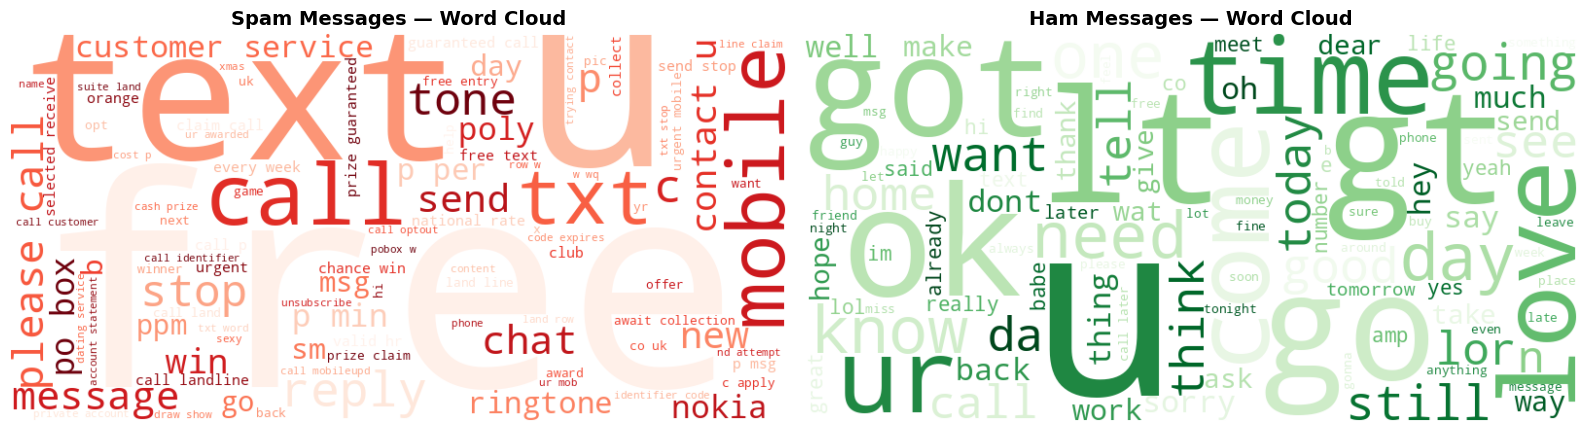

In [9]:
spam_text = ' '.join(df[df['label'] == 1]['text'])
ham_text  = ' '.join(df[df['label'] == 0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_spam = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Spam Messages — Word Cloud', fontsize=14, fontweight='bold')

wc_ham = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Ham Messages — Word Cloud', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## **8. TRAIN-TEST SPLIT**

In [10]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 4457, Test size: 1115


## **9. TOKENIZATION**

In [11]:
# Limit vocabulary to top 10,000 most frequent words
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

vocab_size = min(len(tokenizer.word_index) + 1, 10000)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 6242


## **10. PADDING**

In [12]:
# Use 95th percentile of training sequence lengths as MAX_LEN
seq_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(seq_lengths, 95))
print(f"MAX_LEN (95th percentile): {max_len}")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

print(f"Train shape: {X_train_pad.shape}, Test shape: {X_test_pad.shape}")

MAX_LEN (95th percentile): 21
Train shape: (4457, 21), Test shape: (1115, 21)


## **11. EARLY STOPPING**

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## **12. MODEL 1 — SIMPLE RNN (BUILD)**

In [14]:
model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## **13. TRAIN RNN**

In [15]:
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9429 - loss: 0.1718 - val_accuracy: 0.9731 - val_loss: 0.0948
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9918 - loss: 0.0324 - val_accuracy: 0.9641 - val_loss: 0.1342
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9958 - loss: 0.0197 - val_accuracy: 0.9686 - val_loss: 0.1234
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9948 - loss: 0.0181 - val_accuracy: 0.9709 - val_loss: 0.1610


## **14. MODEL 2 — LSTM (BUILD)**

In [16]:
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## **15. TRAIN LSTM**

In [17]:
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9307 - loss: 0.1978 - val_accuracy: 0.9641 - val_loss: 0.1133
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9913 - loss: 0.0311 - val_accuracy: 0.9709 - val_loss: 0.1254
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9978 - loss: 0.0110 - val_accuracy: 0.9731 - val_loss: 0.1423


## **16. LOAD GLOVE EMBEDDINGS**

In [18]:
embedding_model = api.load('glove-wiki-gigaword-50')
embedding_dim = 50

[==================================================] 100.0% 66.0/66.0MB downloaded


## **17. CREATE EMBEDDING MATRIX**

In [19]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (6242, 50)


## **18. MODEL 3 — LSTM + GloVe (BUILD)**

In [20]:
model_w2v = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_w2v.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       312,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,100 (1.19 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 312,100 (1.19 MB)

## **19. TRAIN WORD2VEC MODEL**

In [21]:
history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9304 - loss: 0.2149 - val_accuracy: 0.9507 - val_loss: 0.1501
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9693 - loss: 0.0922 - val_accuracy: 0.9641 - val_loss: 0.1127
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9753 - loss: 0.0755 - val_accuracy: 0.9709 - val_loss: 0.1036


## **20. TRAINING CURVES**

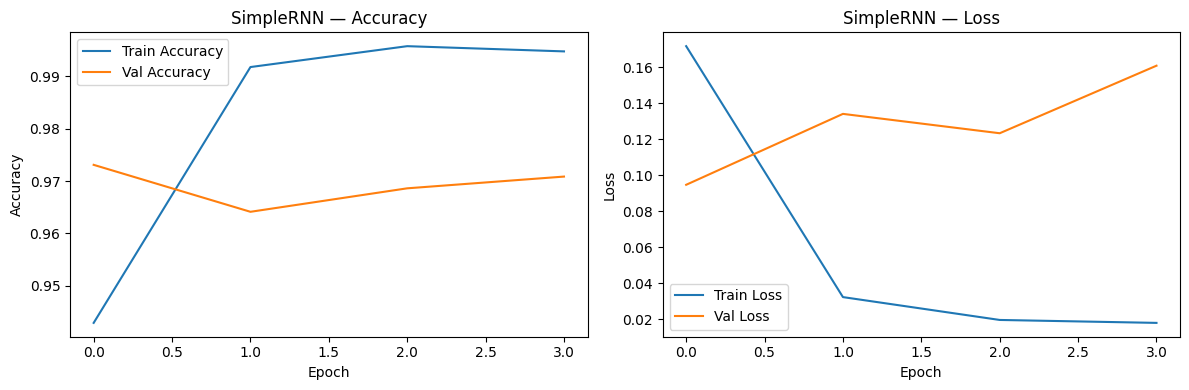

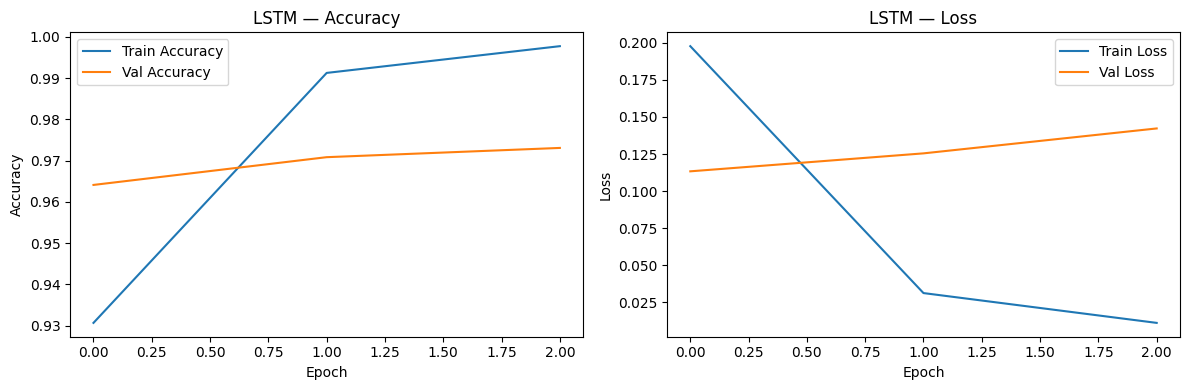

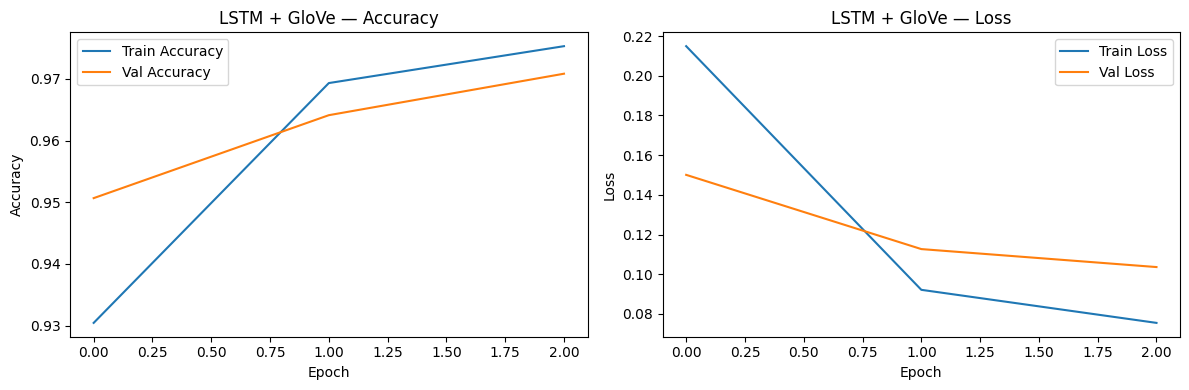

In [22]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_rnn,  'SimpleRNN')
plot_history(history_lstm, 'LSTM')
plot_history(history_w2v,  'LSTM + GloVe')

## **21. EVALUATION FUNCTION**

In [23]:
def evaluate_model(model, X_test, y_test, name):
    preds = (model.predict(X_test) > 0.5).astype('int32')
    print(f'\n========== {name} ==========')
    print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    return accuracy_score(y_test, preds)

## **22. FINAL EVALUATION**

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

========== SimpleRNN ==========
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       965
        Spam       0.96      0.88      0.92       150

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



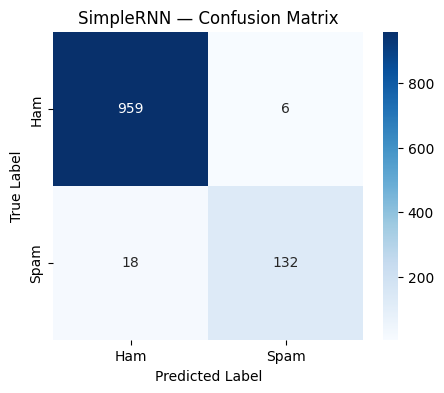

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

========== LSTM ==========
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       0.99      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



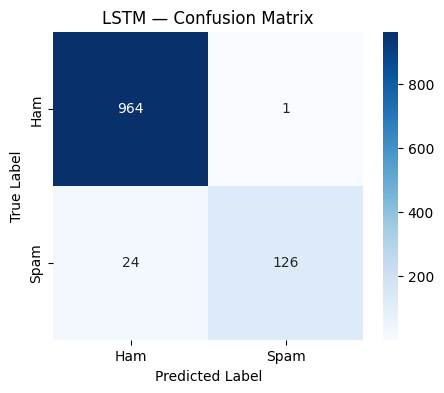

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

========== LSTM + GloVe ==========
              precision    recall  f1-score   support

         Ham       0.96      0.99      0.98       965
        Spam       0.94      0.73      0.82       150

    accuracy                           0.96      1115
   macro avg       0.95      0.86      0.90      1115
weighted avg       0.96      0.96      0.95      1115



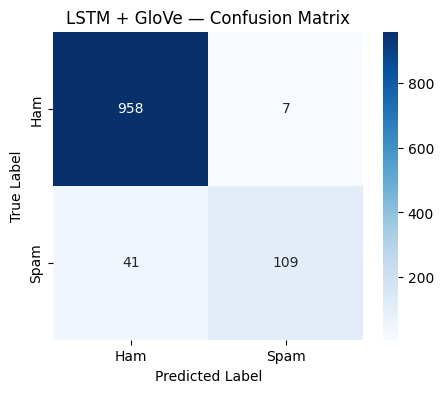

In [24]:
rnn_acc  = evaluate_model(model_rnn,  X_test_pad, y_test, 'SimpleRNN')
lstm_acc = evaluate_model(model_lstm, X_test_pad, y_test, 'LSTM')
w2v_acc  = evaluate_model(model_w2v,  X_test_pad, y_test, 'LSTM + GloVe')

## **23. ACCURACY COMPARISON BAR CHART**

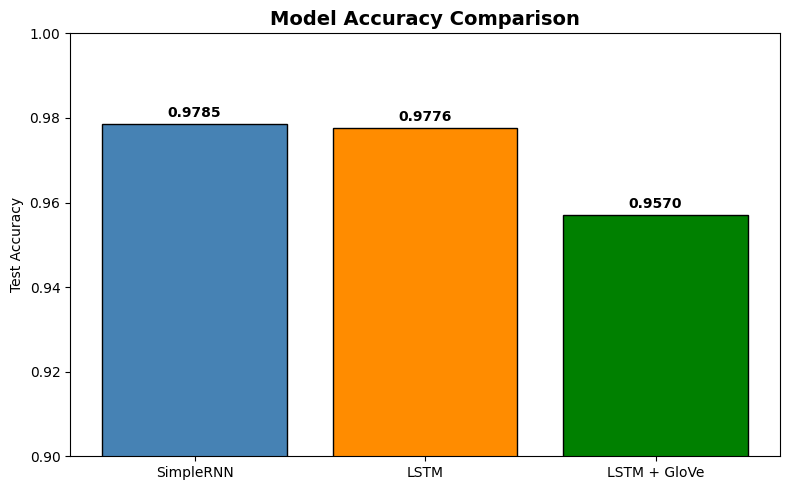


SimpleRNN  : 0.9785
LSTM       : 0.9776
LSTM+GloVe : 0.9570


In [25]:
models   = ['SimpleRNN', 'LSTM', 'LSTM + GloVe']
accuracy = [rnn_acc, lstm_acc, w2v_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracy, color=['steelblue', 'darkorange', 'green'], edgecolor='black')
plt.ylim(0.9, 1.0)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy')

for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nSimpleRNN  : {rnn_acc:.4f}')
print(f'LSTM       : {lstm_acc:.4f}')
print(f'LSTM+GloVe : {w2v_acc:.4f}')

## **24. ERROR ANALYSIS**

In [26]:
# Get predictions from SimpleRNN
rnn_preds = (model_rnn.predict(X_test_pad) > 0.5).astype('int32').flatten()

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

errors = pd.DataFrame({
    'text':      X_test_reset,
    'true':      y_test_reset,
    'predicted': rnn_preds
})
errors = errors[errors['true'] != errors['predicted']]

print(f'Total errors: {len(errors)}')
print('\n--- FALSE NEGATIVES (Spam predicted as Ham) ---')
fn = errors[errors['true'] == 1]
print(fn[['text', 'true', 'predicted']].head(5).to_string())

print('\n--- FALSE POSITIVES (Ham predicted as Spam) ---')
fp = errors[errors['true'] == 0]
print(fp[['text', 'true', 'predicted']].head(5).to_string())

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Total errors: 24

--- FALSE NEGATIVES (Spam predicted as Ham) ---
                                                                                           text  true  predicted
32   hi sue year old work lapdancer love sex text live bedroom text sue textoperator g da ppmsg     1          0
221           tddnewsletter co uk game thedailydraw dear helen dozen free game great prizeswith     1          0
225                                                                                ringtoneking     1          0
364                                                                                   pm cost p     1          0
448  email alertfrom jeri stewartsize kbsubject low cost prescripiton drvgsto listen email call     1          0

--- FALSE POSITIVES (Ham predicted as Spam) ---
                                                                           text  true  predicted
231     true passable get high score apply phd get year salary make lif

## **25. REAL-TIME GUI USING GRADIO**

In [27]:
def predict_message(message):
    cleaned   = clean_text(message)
    sequence  = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    prob      = model_lstm.predict(padded, verbose=0)[0][0]
    label     = 'SPAM' if prob > 0.5 else 'HAM'
    confidence = prob if prob > 0.5 else 1 - prob
    return f'{label}  ({confidence*100:.1f}% confidence)'

demo = gr.Interface(
    fn=predict_message,
    inputs=gr.Textbox(lines=3, placeholder='Type or paste an SMS message here...', label='Input Message'),
    outputs=gr.Textbox(label='Prediction'),
    title='SMS Spam Detector',
    description='Uses a trained LSTM model to classify SMS messages as SPAM or HAM.',
    examples=[
        ['You have won a FREE prize! Call now to claim your reward!'],
        ['Hey are you coming to class tomorrow?'],
        ['Congratulations! You have been selected for a 900 prize reward!'],
        ['Can you pick up some milk on your way home?']
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4228624f7aacf60312.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
